In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [4]:
df = pd.read_csv("underfitting_dataset.csv")
df

,Study_Hours,Marks
0,1,1
1,1,3
2,1,2
3,2,1
4,2,4
5,2,3
6,3,2
7,3,5
8,3,4
9,4,2


In [6]:
x = df[["Study_Hours"]]
y = df["Marks"]

In [8]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.4,random_state = 42)

In [10]:
x_train

,Study_Hours
5,2
13,5
11,4
22,8
1,1
2,1
25,9
3,2
21,8
26,9


In [12]:
model = LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)

In [16]:
y_train_pred

array([ 2.88210607,  5.83746662,  4.85234643,  8.79282717,  1.89698588,
        1.89698588,  9.77794735,  2.88210607,  8.79282717,  9.77794735,
        7.80770698, 10.76306753,  7.80770698,  3.86722625,  4.85234643,
        5.83746662,  7.80770698,  3.86722625])

In [18]:
train_mse = mean_squared_error(y_train,y_train_pred)
test_mse = mean_squared_error(y_test,y_test_pred)

In [20]:
print("Training MSE:", train_mse)
print("Testing MSE:", test_mse)

Training MSE: 1.8037644664886174
Testing MSE: 3.7140188378596974


In [22]:
residuals = y_test - y_test_pred
residuals

27   -2.763068
15   -2.822587
23    0.207173
17    0.177413
8     0.132774
9    -2.852346
28    1.236932
24   -2.777947
12   -2.837467
0    -0.896986
4     1.117894
16    1.177413
Name: Marks, dtype: float64

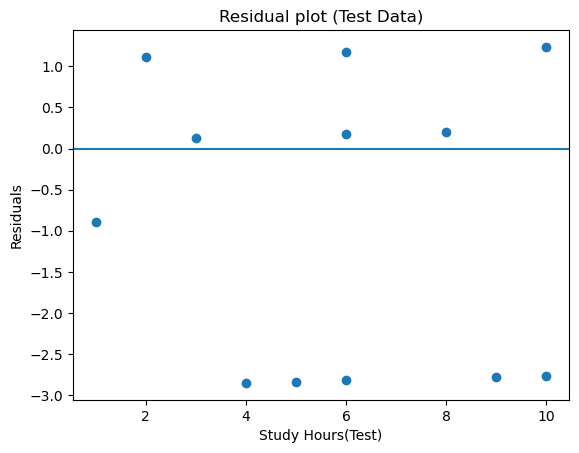

In [24]:
plt.figure()
plt.scatter(x_test, residuals)
plt.axhline(0)
plt.xlabel("Study Hours(Test)")
plt.ylabel("Residuals")
plt.title("Residual plot (Test Data)")
plt.show()